In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = pd.read_csv('/content/drive/MyDrive/Time_Series/tea_vs_coffee_global_final.csv', parse_dates=['year'],index_col='year')

data.head()

,country,continent,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,drink_temperature,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
year,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Bangladesh,Asia,56,Male,Low,Coffee,Mocha,Modern,2.3,Both,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
2015-01-01,Bangladesh,Asia,61,Other,High,Tea,Oolong Tea,Traditional,1.3,Both,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2015-01-01,Bangladesh,Asia,59,Female,Low,Coffee,Americano,Modern,3.2,Cold,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
2015-01-01,Bangladesh,Asia,41,Other,High,Coffee,Cappuccino,Modern,3.0,Cold,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
2015-01-01,Bangladesh,Asia,43,Other,Middle,Tea,Green Tea,Traditional,1.9,Hot,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


,cups_per_day,monthly_spend
year,,
2015-01-01,3772.6,76394.1
2015-02-01,0.0,0.0
2015-03-01,0.0,0.0
2015-04-01,0.0,0.0
2015-05-01,0.0,0.0


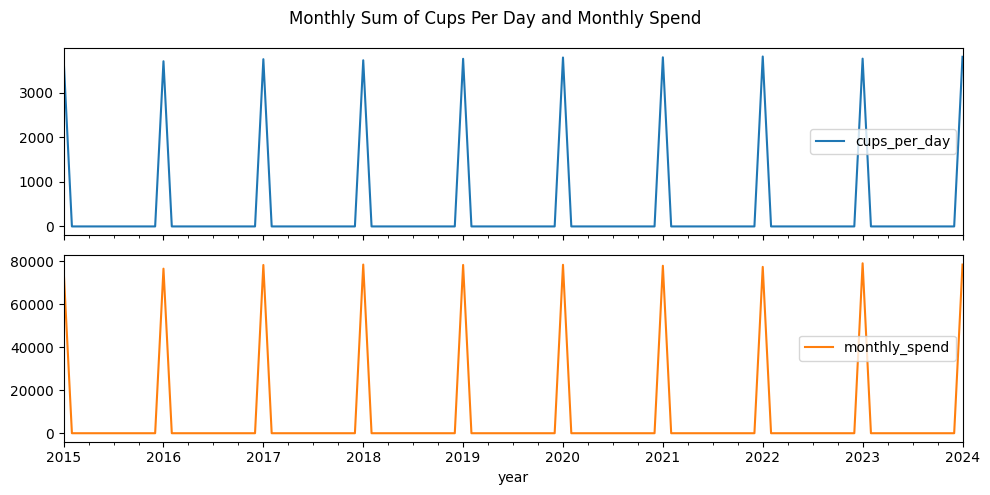

In [48]:
# Select only the relevant numerical columns for time series analysis
numeric_cols = ['cups_per_day', 'monthly_spend']
data_monthly = data[numeric_cols].resample('MS').sum().fillna(0)

display(data_monthly.head())
data_monthly.plot(subplots=True, figsize=(10, 5), title='Monthly Sum of Cups Per Day and Monthly Spend')
plt.tight_layout()
plt.show()

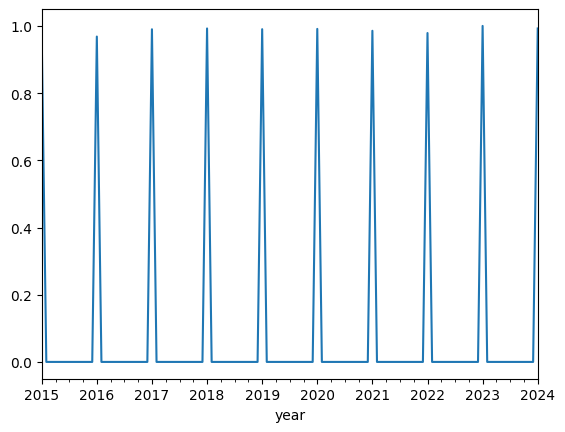

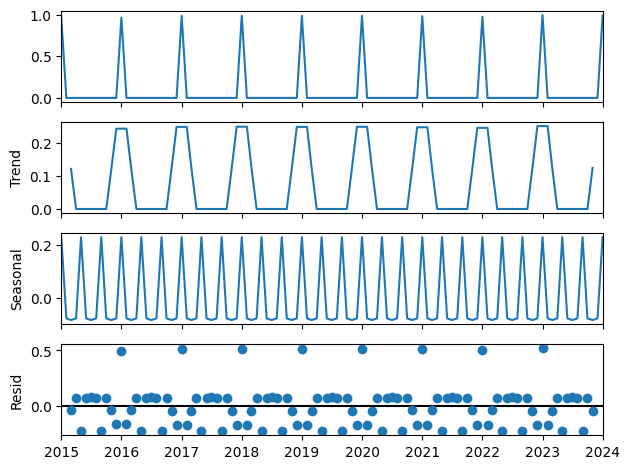

In [49]:
scaler = MinMaxScaler()
time_series_to_decompose = data_monthly['monthly_spend'].to_frame()
scaled_series_values = scaler.fit_transform(time_series_to_decompose.values).flatten()
scaled_data = pd.Series(scaled_series_values, index=data_monthly.index)

scaled_data.plot()
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(scaled_data, model="additive", period=4)
decomposition.plot()
plt.show()

(np.float64(0.2858386878070907), np.float64(1.0904223916079951))

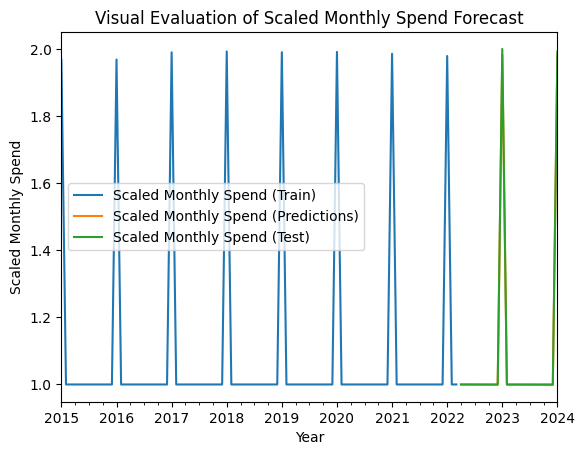

In [50]:
scaled_data=scaled_data+1 # multiplicative seasonality cant handle non postive values, ye
train_data = scaled_data[:int(len(scaled_data) * 0.8)]
test_data = scaled_data[int(len(scaled_data) * 0.8):]
model_add = ExponentialSmoothing(train_data, trend='add', seasonal='mul').fit()
test_predictions_add = model_add.forecast(steps=len(test_data))
ax=train_data.plot()
test_predictions_add.plot(ax=ax)
test_data.plot(ax=ax)
ax.legend(["Scaled Monthly Spend (Train)", "Scaled Monthly Spend (Predictions)","Scaled Monthly Spend (Test)"])
ax.set_title('Visual Evaluation of Scaled Monthly Spend Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Scaled Monthly Spend')
np.sqrt(mean_squared_error(test_data, test_predictions_add))
np.sqrt(scaled_data.var()),scaled_data.mean()

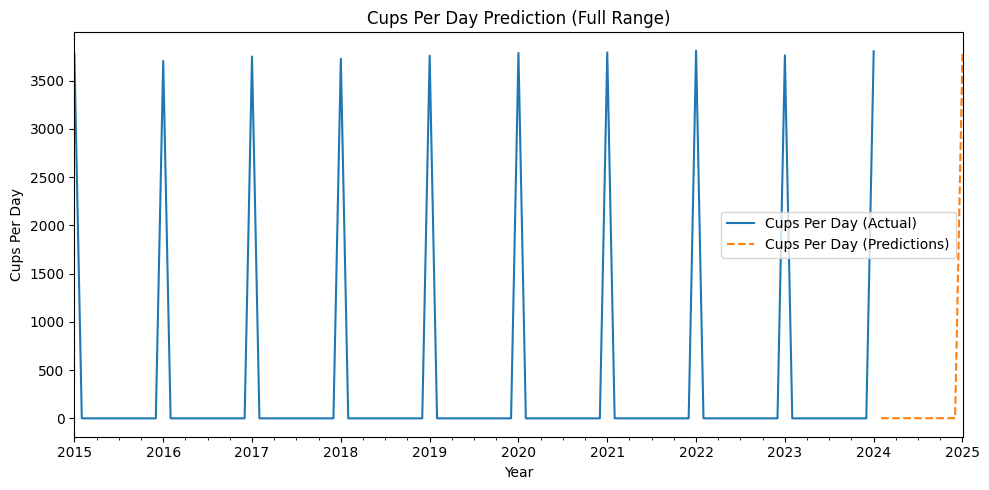

In [55]:
positive_cups_per_day = data_monthly['cups_per_day'] + 1

final_model = ExponentialSmoothing(positive_cups_per_day, trend='add', seasonal='add', seasonal_periods=12).fit()
final_predictions = final_model.forecast(steps=12) # Forecast for a full year

plt.figure(figsize=(10, 5))

# Full historical data with predictions
ax = data_monthly['cups_per_day'].plot(label='Cups Per Day (Actual)')
(final_predictions - 1).plot(ax=ax, label='Cups Per Day (Predictions)', linestyle='--')
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Cups Per Day')
ax.set_title('Cups Per Day Prediction (Full Range)')

plt.tight_layout()
plt.show()